# TPAMI Figures

Adapted for the four-group comparison study.
Files loaded from `acc_results/Summaries Copy/`.

In [1]:
import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        9,
    "axes.titlesize":   9,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "legend.fontsize":  8,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

FULL_W = 7.16
ROW_H  = 2.8

DATASETS_ORDERED = [
    "Fish", "EuroSAT", "UCM", "Marine",
    "Flowers102", "OxfordPets", "CUB200", "Dissertation"
]

DATASET_COLORS = {
    "EuroSAT":     "#1f77b4",
    "UCM":         "#ff7f0e",
    "Fish":        "#2ca02c",
    "Marine":      "#d62728",
    "Flowers102":  "#8c564b",
    "OxfordPets":  "#e377c2",
    "CUB200":      "#7f7f7f",
    "Dissertation":"#bcbd22",
}

# One marker per model
MODEL_MARKERS = {
    "OpenCLIP-ViT-B-16":  "o",   # shared baseline — circle
    "OpenCLIP-ViT-L-14":  "s",   # scale
    "OpenCLIP-ViT-H-14":  "^",   # scale
    "ConvNeXt-B":         "D",   # architecture
    "SigLIP-ViT-B-16":    "P",   # objective v1
    "SigLIP2-ViT-B-16":   "X",   # objective v2
    "MetaCLIP-ViT-B-16":  "v",   # data
    "DataComp-ViT-B-16":  "h",   # data
}

MODEL_SHORT = {
    "OpenCLIP-ViT-B-16":  "OC-ViT-B-16",
    "OpenCLIP-ViT-L-14":  "OC-ViT-L-14",
    "OpenCLIP-ViT-H-14":  "OC-ViT-H-14",
    "ConvNeXt-B":         "ConvNeXt-B",
    "SigLIP-ViT-B-16":    "SigLIP-B-16",
    "SigLIP2-ViT-B-16":   "SigLIP2-B-16",
    "MetaCLIP-ViT-B-16":  "MetaCLIP-B-16",
    "DataComp-ViT-B-16":  "DataComp-B-16",
}

# Group colour for the four comparison charts
GROUP_PALETTES = {
    "scale":      ["#4878d0", "#6acc65", "#d65f5f"],
    "arch":       ["#4878d0", "#8c613c"],
    "objective":  ["#4878d0", "#956cb4", "#c05080"],
    "data":       ["#4878d0", "#ee854a", "#59a14f"],
}

print("Setup complete.")

Setup complete.


## Load data

Loads all five JSON files and merges them.
`OpenCLIP-ViT-B-16` appears in every group file — we deduplicate so it is counted once in aggregate analyses (scatter, heatmap) but kept in each group file for comparison charts.

In [2]:
notebook_dir  = Path().resolve()
acc_results   = notebook_dir.parent / "acc_results"
summaries_dir = acc_results / "Summaries Copy"

FILES = {
    "baseline":     summaries_dir / "_ViT-B-16_Baselines_combined.json",
    "scale":        summaries_dir / "_Scale_combined.json",
    "architecture": summaries_dir / "_Architecture_combined.json",
    "objective":    summaries_dir / "_Objective_combined.json",
    "data":         summaries_dir / "_Data_combined.json",
}

group_data = {}
for group, path in FILES.items():
    with open(path) as f:
        group_data[group] = json.load(f)
    print(f"  {group:<14}: {len(group_data[group])} entries  "
          f"models: {sorted(set(e['model'] for e in group_data[group]))}")

# all_data is simply every entry from every file — no deduplication needed
# because OpenCLIP-ViT-B-16 only appears in the baseline file
all_data = [e for entries in group_data.values() for e in entries]

datasets = [d for d in DATASETS_ORDERED if d in {e['dataset'] for e in all_data}]
print(f"\nTotal entries : {len(all_data)}")
print(f"Datasets      : {datasets}")
print(f"Models        : {sorted(set(e['model'] for e in all_data))}")

def get_entry(model, dataset, source=None):
    """Look up a (model, dataset) pair.
    Searches 'source' first; always falls back to the baseline file
    for OpenCLIP-ViT-B-16 since that model is not in any group file.
    """
    src = source if source is not None else all_data
    result = next((d for d in src
                   if d['model'] == model and d['dataset'] == dataset), None)
    if result is None and model == "OpenCLIP-ViT-B-16":
        result = next((d for d in group_data['baseline']
                       if d['dataset'] == dataset), None)
    return result

  baseline      : 8 entries  models: ['OpenCLIP-ViT-B-16']
  scale         : 16 entries  models: ['OpenCLIP-ViT-H-14', 'OpenCLIP-ViT-L-14']
  architecture  : 8 entries  models: ['ConvNeXt-B']
  objective     : 16 entries  models: ['SigLIP-ViT-B-16', 'SigLIP2-ViT-B-16']
  data          : 16 entries  models: ['DataComp-ViT-B-16', 'MetaCLIP-ViT-B-16']

Total entries : 64
Datasets      : ['Fish', 'EuroSAT', 'UCM', 'Marine', 'Flowers102', 'OxfordPets', 'CUB200', 'Dissertation']
Models        : ['ConvNeXt-B', 'DataComp-ViT-B-16', 'MetaCLIP-ViT-B-16', 'OpenCLIP-ViT-B-16', 'OpenCLIP-ViT-H-14', 'OpenCLIP-ViT-L-14', 'SigLIP-ViT-B-16', 'SigLIP2-ViT-B-16']


## Fig 1 — Baseline accuracy vs Δp

All 64 unique (model, dataset) combinations. Colour = dataset, marker = model.
Regression line uses all points; Dissertation excluded from regression to avoid ceiling-effect leverage.

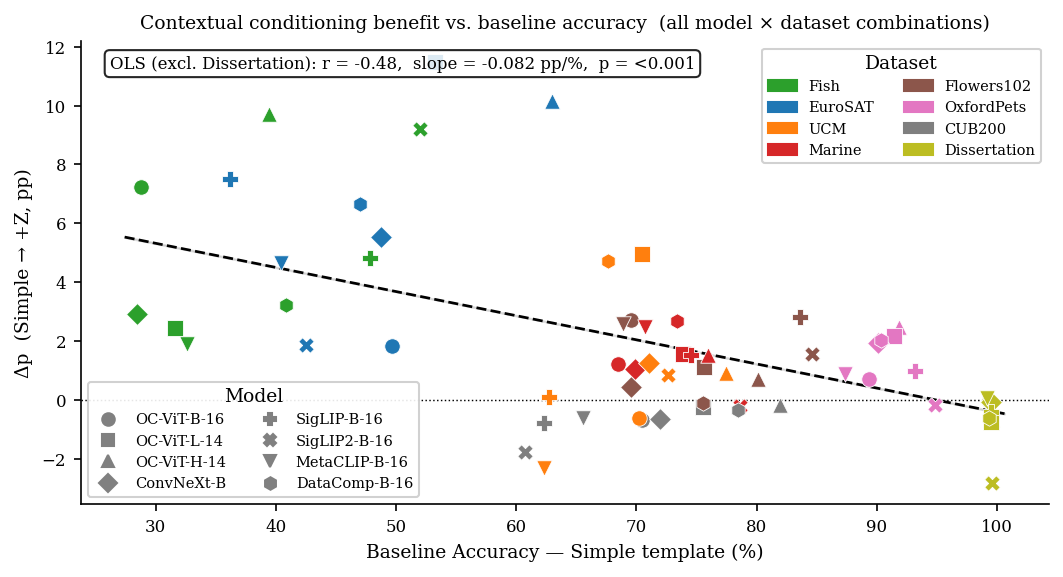

r = -0.484   p = 0.0002   slope = -0.0820


In [3]:
EXCLUDE_FROM_REG = {"Dissertation"}  # ceiling dataset — strong leverage point

fig, ax = plt.subplots(figsize=(FULL_W, ROW_H * 1.4))

xs_all, ys_all = [], []
xs_reg, ys_reg = [], []

for entry in all_data:
    x  = entry["simple_acc"]
    y  = entry["delta_p_stats"]["delta_p"]
    ds = entry["dataset"]
    m  = entry["model"]
    ax.scatter(x, y,
               color=DATASET_COLORS.get(ds, "grey"),
               marker=MODEL_MARKERS.get(m, "o"),
               s=55, zorder=3,
               edgecolors="white", linewidths=0.4)
    xs_all.append(x); ys_all.append(y)
    if ds not in EXCLUDE_FROM_REG:
        xs_reg.append(x); ys_reg.append(y)

xs_reg = np.array(xs_reg); ys_reg = np.array(ys_reg)
xs_all = np.array(xs_all); ys_all = np.array(ys_all)

# OLS on non-ceiling points
slope, intercept, r, p, se = stats.linregress(xs_reg, ys_reg)
x_line = np.linspace(xs_all.min() - 1, xs_all.max() + 1, 300)
y_line = slope * x_line + intercept
p_str  = "<0.001" if p < 0.001 else f"{p:.3f}"
ax.plot(x_line, y_line, "k--", linewidth=1.3, zorder=2)

n     = len(xs_reg)
se_y  = np.sqrt(se**2 * ((x_line - xs_reg.mean())**2
                / ((xs_reg - xs_reg.mean())**2).sum() + 1/n))
t_crit = stats.t.ppf(0.975, df=n - 2)
ax.fill_between(x_line, y_line - t_crit*se_y, y_line + t_crit*se_y,
                alpha=0.12, color="black", zorder=1)

ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax.text(0.03, 0.97,
        f"OLS (excl. Dissertation): r = {r:.2f},  slope = {slope:.3f} pp/%,  p = {p_str}",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

# Legends
ds_handles = [mpatches.Patch(color=DATASET_COLORS[d], label=d)
              for d in DATASETS_ORDERED if d in {e["dataset"] for e in all_data}]
m_handles  = [Line2D([0],[0], marker=MODEL_MARKERS[m], color="grey",
                     linestyle="None", markersize=6, label=MODEL_SHORT[m])
              for m in MODEL_SHORT if m in {e["model"] for e in all_data}]

leg1 = ax.legend(handles=ds_handles, title="Dataset",
                 loc="upper right", ncol=2, framealpha=0.9, fontsize=7)
ax.add_artist(leg1)
ax.legend(handles=m_handles, title="Model",
          loc="lower left", ncol=2, framealpha=0.9, fontsize=7)

ax.set_xlabel("Baseline Accuracy — Simple template (%)")
ax.set_ylabel("Δp  (Simple → +Z, pp)")
ax.set_title("Contextual conditioning benefit vs. baseline accuracy  (all model × dataset combinations)")

plt.tight_layout()
plt.savefig("fig1_baseline_vs_deltap.pdf")
plt.savefig("fig1_baseline_vs_deltap.png", dpi=300)
plt.show()
print(f"r = {r:.3f}   p = {p:.4f}   slope = {slope:.4f}")

## Attach domain accuracy (needed for Fig 2)

Scans all result subfolders for `*_domain.json` files saved by `run_experiment.py`.
Update `RESULTS_ROOT` if needed.

In [4]:
RESULTS_ROOT = acc_results  # folder to scan for *_domain.json files

def attach_domain_acc(data, results_root):
    enriched = 0
    for root, _, files in os.walk(results_root):
        for fname in files:
            if not fname.endswith("_domain.json"):
                continue
            try:
                with open(os.path.join(root, fname)) as f:
                    dom = json.load(f)
                model      = dom.get("model")
                dataset    = dom.get("dataset")
                domain_acc = dom.get("accuracy")
                if model and dataset and domain_acc is not None:
                    for entry in data:
                        if entry["model"] == model and entry["dataset"] == dataset:
                            entry["domain_acc"] = domain_acc
                            enriched += 1
            except Exception as e:
                print(f"  Skipped {fname}: {e}")
    return data, enriched

all_data, n_enriched = attach_domain_acc(all_data, RESULTS_ROOT)
has_domain = [e for e in all_data if "domain_acc" in e]
print(f"Attached domain_acc to {n_enriched} entries")
print(f"{len(has_domain)} / {len(all_data)} entries ready for Fig 2")

Attached domain_acc to 64 entries
64 / 64 entries ready for Fig 2


## Fig 2 — Pipeline decomposition

X = Δp(Simple → Domain), Y = Δp(Domain → +Z).
Shows where in the two-step pipeline benefit and harm originate.

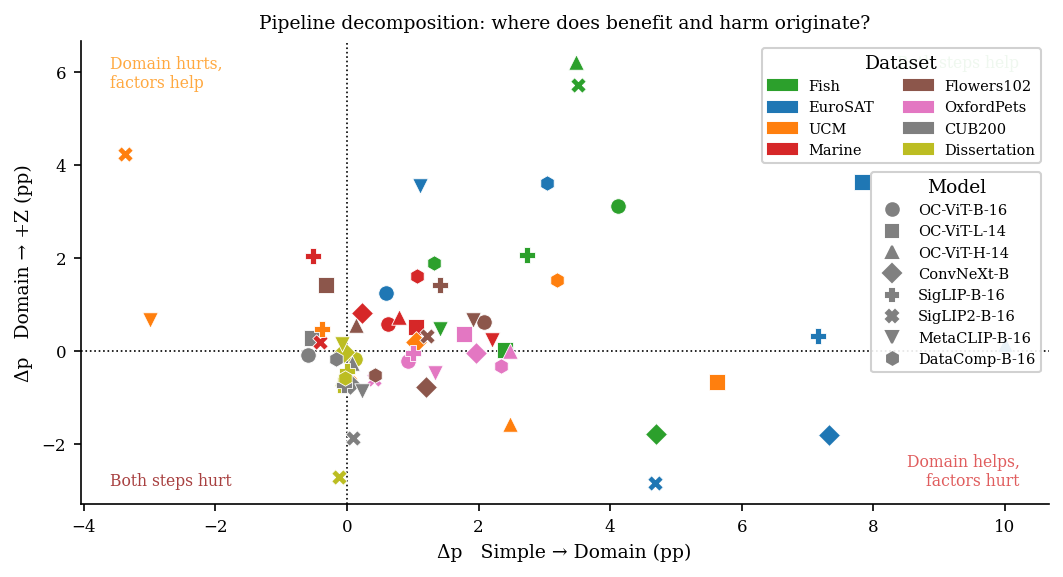


Both steps help:           28  (44%)
Domain helps, +Z hurts:    20  (31%)
Domain hurts, +Z helps:     8  (12%)
Both steps hurt:            8  (12%)


In [5]:
has_domain = [e for e in all_data if "domain_acc" in e]

if not has_domain:
    print("No domain_acc found. Check RESULTS_ROOT in the cell above.")
else:
    fig, ax = plt.subplots(figsize=(FULL_W, ROW_H * 1.4))

    for entry in has_domain:
        x  = entry["domain_acc"] - entry["simple_acc"]
        y  = entry["plus_z_acc"] - entry["domain_acc"]
        ds = entry["dataset"]
        m  = entry["model"]
        ax.scatter(x, y,
                   color=DATASET_COLORS.get(ds, "grey"),
                   marker=MODEL_MARKERS.get(m, "o"),
                   s=55, zorder=3,
                   edgecolors="white", linewidths=0.4)

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")

    kw = dict(transform=ax.transAxes, fontsize=7.5, alpha=0.75)
    ax.text(0.97, 0.97, "Both steps help",     ha="right", va="top",    color="#2ca02c",   **kw)
    ax.text(0.03, 0.97, "Domain hurts,\nfactors help", ha="left",  va="top",    color="darkorange", **kw)
    ax.text(0.97, 0.03, "Domain helps,\nfactors hurt", ha="right", va="bottom", color="#d62728",  **kw)
    ax.text(0.03, 0.03, "Both steps hurt",     ha="left",  va="bottom", color="darkred",   **kw)

    ds_handles = [mpatches.Patch(color=DATASET_COLORS[d], label=d)
                  for d in DATASETS_ORDERED if d in {e["dataset"] for e in has_domain}]
    m_handles  = [Line2D([0],[0], marker=MODEL_MARKERS[m], color="grey",
                         linestyle="None", markersize=6, label=MODEL_SHORT[m])
                  for m in MODEL_SHORT if m in {e["model"] for e in has_domain}]

    leg1 = ax.legend(handles=ds_handles, title="Dataset",
                     loc="upper right", ncol=2, framealpha=0.9, fontsize=7)
    ax.add_artist(leg1)
    ax.legend(handles=m_handles, title="Model",
              loc="center right", ncol=1, framealpha=0.9, fontsize=7)

    ax.set_xlabel("Δp   Simple → Domain (pp)")
    ax.set_ylabel("Δp   Domain → +Z (pp)")
    ax.set_title("Pipeline decomposition: where does benefit and harm originate?")

    plt.tight_layout()
    plt.savefig("fig2_domain_decomposition.pdf")
    plt.savefig("fig2_domain_decomposition.png", dpi=300)
    plt.show()

    # Quadrant counts
    q = {"both_help":0,"domain_only":0,"factors_only":0,"both_hurt":0}
    for e in has_domain:
        x = e["domain_acc"] - e["simple_acc"]
        y = e["plus_z_acc"] - e["domain_acc"]
        if   x >= 0 and y >= 0: q["both_help"]    += 1
        elif x <  0 and y >= 0: q["factors_only"] += 1
        elif x >= 0 and y <  0: q["domain_only"]  += 1
        else:                    q["both_hurt"]    += 1
    total = len(has_domain)
    print(f"\nBoth steps help:          {q['both_help']:>3}  ({100*q['both_help']/total:.0f}%)")
    print(f"Domain helps, +Z hurts:   {q['domain_only']:>3}  ({100*q['domain_only']/total:.0f}%)")
    print(f"Domain hurts, +Z helps:   {q['factors_only']:>3}  ({100*q['factors_only']/total:.0f}%)")
    print(f"Both steps hurt:          {q['both_hurt']:>3}  ({100*q['both_hurt']/total:.0f}%)")

## Fig 3 — Δp heatmap (dataset × model)

All 8 models × 8 datasets. Columns ordered by comparison group.

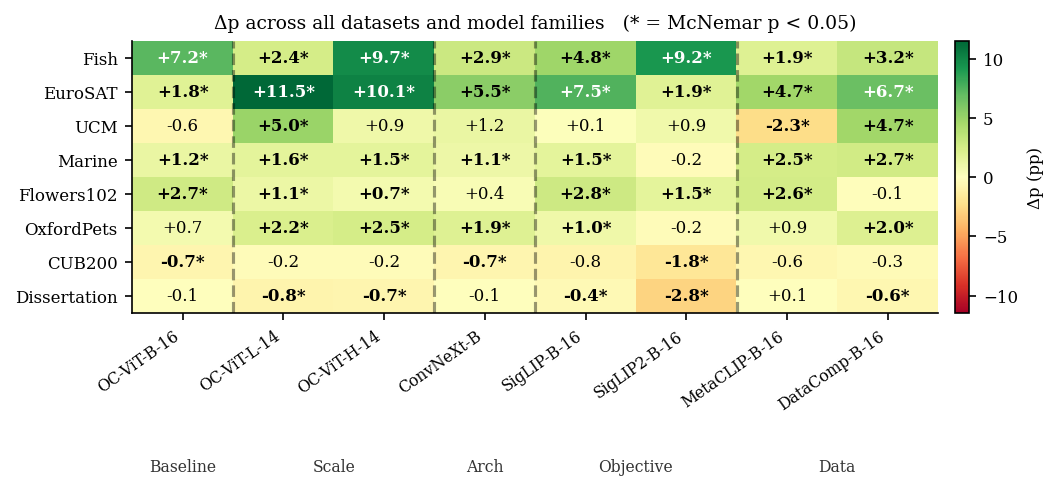

In [6]:
models_ordered = [
    "OpenCLIP-ViT-B-16",                          # shared baseline
    "OpenCLIP-ViT-L-14", "OpenCLIP-ViT-H-14",    # scale
    "ConvNeXt-B",                                  # architecture
    "SigLIP-ViT-B-16",   "SigLIP2-ViT-B-16",     # objective
    "MetaCLIP-ViT-B-16", "DataComp-ViT-B-16",    # data
]
models_ordered = [m for m in models_ordered if m in {e["model"] for e in all_data}]

matrix = np.full((len(datasets), len(models_ordered)), np.nan)
sig_mat = np.full((len(datasets), len(models_ordered)), False)

for entry in all_data:
    ds = entry["dataset"]
    m  = entry["model"]
    if ds in datasets and m in models_ordered:
        r = datasets.index(ds)
        c = models_ordered.index(m)
        matrix[r, c]  = entry["delta_p_stats"]["delta_p"]
        sig_mat[r, c] = entry["delta_p_stats"]["significant"] == "True"

fig, ax = plt.subplots(figsize=(FULL_W, ROW_H * 1.5))
vmax = np.nanmax(np.abs(matrix))
im   = ax.imshow(matrix, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

# Cell annotations
for r in range(len(datasets)):
    for c in range(len(models_ordered)):
        if not np.isnan(matrix[r, c]):
            val  = matrix[r, c]
            star = "*" if sig_mat[r, c] else ""
            fc   = "white" if abs(val) > vmax * 0.55 else "black"
            ax.text(c, r, f"{val:+.1f}{star}",
                    ha="center", va="center", fontsize=8,
                    color=fc, fontweight="bold" if sig_mat[r, c] else "normal")

# Group separator lines
# Between baseline and scale, between scale and arch, etc.
group_boundaries = [0.5, 2.5, 3.5, 5.5]  # after columns 0, 2, 3, 5
for xb in group_boundaries:
    ax.axvline(xb, color="black", linewidth=1.5, linestyle="--", alpha=0.4)

# Group labels above
group_labels = [
    (0,   0,   "Baseline"),
    (1,   2,   "Scale"),
    (3,   3,   "Arch"),
    (4,   5,   "Objective"),
    (6,   7,   "Data"),
]
for c_start, c_end, label in group_labels:
    ax.annotate(label,
                xy=((c_start + c_end) / 2, -0.6),
                xycoords=("data", "axes fraction"),
                ha="center", va="bottom",
                fontsize=7.5, color="#333333",
                annotation_clip=False)

ax.set_xticks(range(len(models_ordered)))
ax.set_xticklabels([MODEL_SHORT[m] for m in models_ordered], rotation=35, ha="right", fontsize=7.5)
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets)

cb = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.02)
cb.set_label("Δp (pp)", fontsize=8)
ax.set_title("Δp across all datasets and model families   (* = McNemar p < 0.05)")

plt.tight_layout()
plt.savefig("fig3_deltap_heatmap.pdf")
plt.savefig("fig3_deltap_heatmap.png", dpi=300)
plt.show()

## Fig 4 — Four comparison bar charts

One subplot per research question. Three models per group where available.
95% CI error bars. * = McNemar p < 0.05 for individual bars.

/var/folders/cf/vzjr024s7pzgmbs0094j80z40000gn/T/ipykernel_46120/3386058011.py:107: UserWarning: Glyph 8756 (\N{THEREFORE}) missing from font(s) DejaVu Serif.
  plt.savefig("fig4_four_comparisons.pdf")
/var/folders/cf/vzjr024s7pzgmbs0094j80z40000gn/T/ipykernel_46120/3386058011.py:107: UserWarning: Glyph 8756 (\N{THEREFORE}) missing from font(s) DejaVu Serif.
  plt.savefig("fig4_four_comparisons.pdf")
/var/folders/cf/vzjr024s7pzgmbs0094j80z40000gn/T/ipykernel_46120/3386058011.py:108: UserWarning: Glyph 8756 (\N{THEREFORE}) missing from font(s) DejaVu Serif.
  plt.savefig("fig4_four_comparisons.png", dpi=300)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8756 (\N{THEREFORE}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


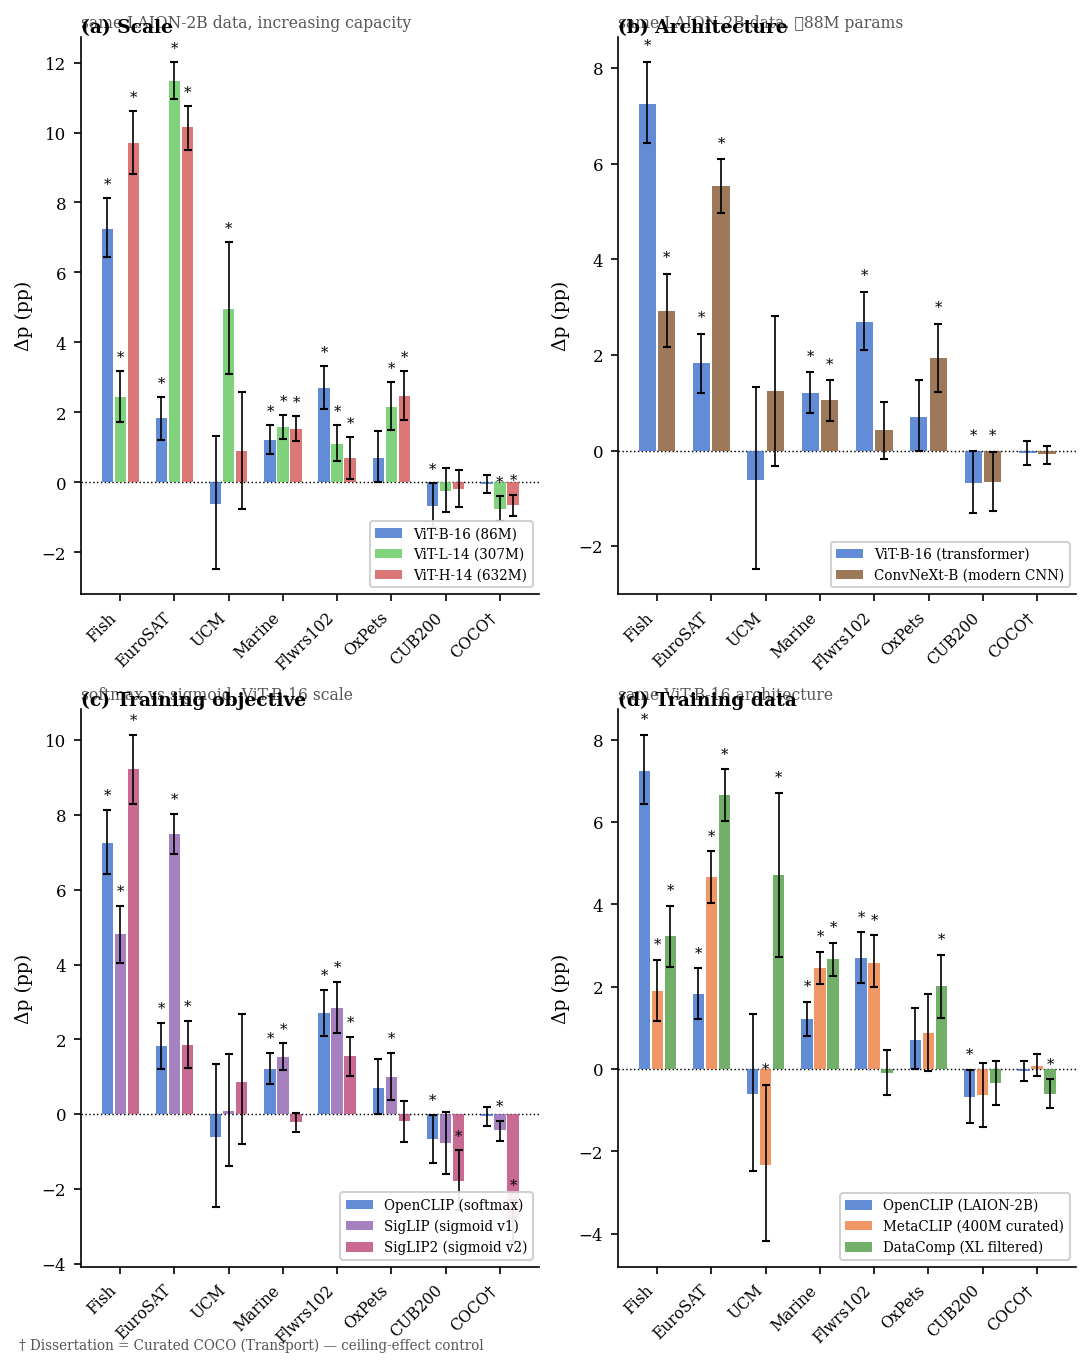

In [8]:
# Short x-axis labels so they don't overlap when rotated
DS_SHORT = {
    "Fish":        "Fish",
    "EuroSAT":     "EuroSAT",
    "UCM":         "UCM",
    "Marine":      "Marine",
    "Flowers102":  "Flwrs102",
    "OxfordPets":  "OxPets",
    "CUB200":      "CUB200",
    "Dissertation": "COCO\u2020",   # dagger to flag it as the control group
}

comparisons = [
    {
        "title":  "(a) Scale",
        "sub":    "same LAION-2B data, increasing capacity",
        "models": ["OpenCLIP-ViT-B-16", "OpenCLIP-ViT-L-14", "OpenCLIP-ViT-H-14"],
        "labels": ["ViT-B-16 (86M)", "ViT-L-14 (307M)", "ViT-H-14 (632M)"],
        "colors": GROUP_PALETTES["scale"],
        "source": group_data["scale"],
    },
    {
        "title":  "(b) Architecture",
        "sub":    "same LAION-2B data, \u223488M params",
        "models": ["OpenCLIP-ViT-B-16", "ConvNeXt-B"],
        "labels": ["ViT-B-16 (transformer)", "ConvNeXt-B (modern CNN)"],
        "colors": GROUP_PALETTES["arch"],
        "source": group_data["architecture"],
    },
    {
        "title":  "(c) Training objective",
        "sub":    "softmax vs sigmoid, ViT-B-16 scale",
        "models": ["OpenCLIP-ViT-B-16", "SigLIP-ViT-B-16", "SigLIP2-ViT-B-16"],
        "labels": ["OpenCLIP (softmax)", "SigLIP (sigmoid v1)", "SigLIP2 (sigmoid v2)"],
        "colors": GROUP_PALETTES["objective"],
        "source": group_data["objective"],
    },
    {
        "title":  "(d) Training data",
        "sub":    "same ViT-B-16 architecture",
        "models": ["OpenCLIP-ViT-B-16", "MetaCLIP-ViT-B-16", "DataComp-ViT-B-16"],
        "labels": ["OpenCLIP (LAION-2B)", "MetaCLIP (400M curated)", "DataComp (XL filtered)"],
        "colors": GROUP_PALETTES["data"],
        "source": group_data["data"],
    },
]

x_labels = [DS_SHORT.get(d, d) for d in datasets]

fig, axes = plt.subplots(2, 2, figsize=(FULL_W, ROW_H * 3.2),
                         constrained_layout=True)
axes = axes.flatten()

for ax, comp in zip(axes, comparisons):
    n_models = len(comp["models"])
    x        = np.arange(len(datasets))
    bar_w    = 0.72 / n_models
    src      = comp["source"]

    for i, (m, lbl, col) in enumerate(zip(comp["models"], comp["labels"], comp["colors"])):
        vals, lo_errs, hi_errs, sigs = [], [], [], []
        for ds in datasets:
            e = get_entry(m, ds, src)
            if e:
                dp  = e["delta_p_stats"]["delta_p"]
                lo  = e["delta_p_stats"]["delta_p_ci"][0]
                hi  = e["delta_p_stats"]["delta_p_ci"][1]
                s   = e["delta_p_stats"]["significant"] == "True"
            else:
                dp = lo = hi = float("nan"); s = False
            vals.append(dp)
            lo_errs.append(dp - lo if dp == dp else 0)
            hi_errs.append(hi - dp if dp == dp else 0)
            sigs.append(s)

        offset = (i - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, vals, bar_w * 0.88,
               color=col, alpha=0.85, label=lbl, zorder=3)
        ax.errorbar(x + offset, vals, yerr=[lo_errs, hi_errs],
                    fmt="none", color="black", capsize=2, linewidth=0.8, zorder=4)

        for xi, (v, hi_e, s) in enumerate(zip(vals, hi_errs, sigs)):
            if s and v == v:
                ax.text(xi + offset, v + hi_e + 0.2, "*",
                        ha="center", va="bottom", fontsize=7)

    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=7.5)
    ax.set_ylabel("\u0394p (pp)", fontsize=9)

    # Two-line title: bold tag + lighter subtitle
    ax.set_title(comp["title"], fontsize=9, fontweight="bold",
                 loc="left", pad=2)
    ax.text(0.0, 1.01, comp["sub"], transform=ax.transAxes,
            fontsize=7.5, color="#555555", va="bottom")

    # Legend always inside, bottom-right (avoids top crowding)
    ax.legend(fontsize=6.5, framealpha=0.9,
              loc="lower right", ncol=1)

# Footnote for dagger
fig.text(0.01, 0.0,
         "\u2020 Dissertation = Curated COCO (Transport) — ceiling-effect control",
         fontsize=6.5, color="#555555", va="bottom")

plt.savefig("fig4_four_comparisons.pdf")
plt.savefig("fig4_four_comparisons.png", dpi=300)
plt.show()